# Task 5 Gate Tester

This notebook loads one random Task 5 input parquet file for a selected `MINGO0*` station, applies configurable gate definitions, and prints the unique column names. Plotting is intentionally left out until requested.

## 1. Gate Definitions

Edit `GATE_CONFIG` here to try different gates. The structure matches `MASTER/CONFIG_FILES/STAGE_1/EVENT_DATA/STEP_1/TASK_5/config_gates_task_5.yaml`.

In [1]:
GATE_CONFIG = {
    "version": 1,
    "gates": {
        "all_events": {
            "bit": 0,
            "description": "All events loaded by Task 5.",
            "expression": "(event_id == event_id)",
        },
    },
}


## 2. Select Station and Load One Random Task 5 File

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

REPO_ROOT = Path("/home/mingo/DATAFLOW_v3")

# Choose the station number in MINGO0*. Examples: 0, 1, 2, 3, 4.
STATION = 4

# Optional reproducibility for random file choice. Set to an int if desired.
RANDOM_SEED = None

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

station_label = f"MINGO0{int(STATION)}"
input_base = REPO_ROOT / "STATIONS" / station_label / "STAGE_1" / "EVENT_DATA" / "STEP_1" / "TASK_5" / "INPUT_FILES"

SEARCH_DIRS = [
    input_base / "UNPROCESSED_DIRECTORY",
    input_base / "COMPLETED_DIRECTORY",
    input_base / "PROCESSING_DIRECTORY",
    input_base / "ERROR_DIRECTORY",
]

def find_parquet_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(directory.glob("*.parquet"))

selected_pool = None
selected_file = None
for directory in SEARCH_DIRS:
    candidates = find_parquet_files(directory)
    if candidates:
        selected_pool = directory.name
        selected_file = random.choice(candidates)
        break

if selected_file is None:
    searched = "\n".join(f"  {directory}" for directory in SEARCH_DIRS)
    raise FileNotFoundError(f"No Task 5 parquet files found for {station_label} in:\n{searched}")

print(f"Station: {station_label}")
print(f"Selected pool: {selected_pool}")
print(f"Selected file: {selected_file}")

df = pd.read_parquet(selected_file)
print(f"Loaded shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())


Station: MINGO04
Selected pool: COMPLETED_DIRECTORY
Selected file: /home/mingo/DATAFLOW_v3/STATIONS/MINGO04/STAGE_1/EVENT_DATA/STEP_1/TASK_5/INPUT_FILES/COMPLETED_DIRECTORY/fitted_mi0426016171545.parquet
Loaded shape: 49,718 rows x 335 columns


,datetime,event_id,acquisition_type,p4_s1_ef_t,p4_s2_ef_t,p4_s3_ef_t,p4_s4_ef_t,p4_s1_eb_t,p4_s2_eb_t,p4_s3_eb_t,p4_s4_eb_t,p4_s1_ef_q,p4_s2_ef_q,p4_s3_ef_q,p4_s4_ef_q,p4_s1_eb_q,p4_s2_eb_q,p4_s3_eb_q,p4_s4_eb_q,p3_s1_ef_t,p3_s2_ef_t,p3_s3_ef_t,p3_s4_ef_t,p3_s1_eb_t,p3_s2_eb_t,p3_s3_eb_t,p3_s4_eb_t,p3_s1_ef_q,p3_s2_ef_q,p3_s3_ef_q,p3_s4_ef_q,p3_s1_eb_q,p3_s2_eb_q,p3_s3_eb_q,p3_s4_eb_q,p2_s1_ef_t,p2_s2_ef_t,p2_s3_ef_t,p2_s4_ef_t,p2_s1_eb_t,p2_s2_eb_t,p2_s3_eb_t,p2_s4_eb_t,p2_s1_ef_q,p2_s2_ef_q,p2_s3_ef_q,p2_s4_ef_q,p2_s1_eb_q,p2_s2_eb_q,p2_s3_eb_q,p2_s4_eb_q,p1_s1_ef_t,p1_s2_ef_t,p1_s3_ef_t,p1_s4_ef_t,p1_s1_eb_t,p1_s2_eb_t,p1_s3_eb_t,p1_s4_eb_t,p1_s1_ef_q,p1_s2_ef_q,p1_s3_ef_q,p1_s4_ef_q,p1_s1_eb_q,p1_s2_eb_q,p1_s3_eb_q,p1_s4_eb_q,param_hash,tt_task0_acq,topology_task1_channel,tt_task0_raw,transferred_task0_acq_to_raw,filter_task1_problematic_channel_count,filter_task1_problematic_channel_exact,tt_task1_clean,transferred_task1_raw_to_clean,p1_s1_tsum,p1_s1_tdif,p1_s1_qsum,p1_s1_qdif,p1_s2_tsum,p1_s2_tdif,p1_s2_qsum,p1_s2_qdif,p1_s3_tsum,p1_s3_tdif,p1_s3_qsum,p1_s3_qdif,p1_s4_tsum,p1_s4_tdif,p1_s4_qsum,p1_s4_qdif,p2_s1_tsum,p2_s1_tdif,p2_s1_qsum,p2_s1_qdif,p2_s2_tsum,p2_s2_tdif,p2_s2_qsum,p2_s2_qdif,p2_s3_tsum,p2_s3_tdif,p2_s3_qsum,p2_s3_qdif,p2_s4_tsum,p2_s4_tdif,p2_s4_qsum,p2_s4_qdif,p3_s1_tsum,p3_s1_tdif,p3_s1_qsum,p3_s1_qdif,p3_s2_tsum,p3_s2_tdif,p3_s2_qsum,p3_s2_qdif,p3_s3_tsum,p3_s3_tdif,p3_s3_qsum,p3_s3_qdif,p3_s4_tsum,p3_s4_tdif,p3_s4_qsum,p3_s4_qdif,p4_s1_tsum,...,event_det_ext_res_tdif_4,event_det_th_chi,event_det_tt_task3_list,event_det_t0,event_tim_x,event_tim_xp,event_tim_y,event_tim_yp,event_tim_t0,event_tim_s,event_tim_th_chi,event_tim_res_y,event_tim_res_ts,event_tim_res_td,event_tim_tt_task3_list,event_tim_res_ystr_1,event_tim_res_ystr_2,event_tim_res_ystr_3,event_tim_res_ystr_4,event_tim_res_tsum_1,event_tim_res_tsum_2,event_tim_res_tsum_3,event_tim_res_tsum_4,event_tim_res_tdif_1,event_tim_res_tdif_2,event_tim_res_tdif_3,event_tim_res_tdif_4,event_tim_ext_res_ystr_1,event_tim_ext_res_ystr_2,event_tim_ext_res_ystr_3,event_tim_ext_res_ystr_4,event_tim_ext_res_tsum_1,event_tim_ext_res_tsum_2,event_tim_ext_res_tsum_3,event_tim_ext_res_tsum_4,event_tim_ext_res_tdif_1,event_tim_ext_res_tdif_2,event_tim_ext_res_tdif_3,event_tim_ext_res_tdif_4,event_tim_p1_qsum,event_tim_p2_qsum,event_tim_p3_qsum,event_tim_p4_qsum,event_tim_event_charge,event_tim_timtrack_iterations,event_tim_timtrack_conv_distance,event_tim_timtrack_converged,event_tim_charge_1,event_tim_charge_2,event_tim_charge_3,event_tim_charge_4,th_chisq_df_0,th_chisq_df_3,th_chisq_df_6,event_tim_theta,event_tim_phi,event_xp,event_yp,p1_ystr_res,p1_tsum_res,p1_tdif_res,p1_ystr_res_ext,p1_tsum_res_ext,p1_tdif_res_ext,p2_ystr_res,p2_tsum_res,p2_tdif_res,p2_ystr_res_ext,p2_tsum_res_ext,p2_tdif_res_ext,p3_ystr_res,p3_tsum_res,p3_tdif_res,p3_ystr_res_ext,p3_tsum_res_ext,p3_tdif_res_ext,p4_ystr_res,p4_tsum_res,p4_tdif_res,p4_ystr_res_ext,p4_tsum_res_ext,p4_tdif_res_ext,event_charge,timtrack_iterations,timtrack_conv_distance,timtrack_converged,event_x,event_x_err,event_y,event_y_err,event_theta,event_theta_err,event_phi,event_phi_err,event_s,event_t0,event_t0_err,p1_ystr_res_err,p2_ystr_res_err,p3_ystr_res_err,p4_ystr_res_err,p1_tsum_res_err,p2_tsum_res_err,p3_tsum_res_err,p4_tsum_res_err,p1_tdif_res_err,p2_tdif_res_err,p3_tdif_res_err,p4_tdif_res_err,p1_ystr_res_ext_err,p2_ystr_res_ext_err,p3_ystr_res_ext_err,p4_ystr_res_ext_err,p1_tsum_res_ext_err,p2_tsum_res_ext_err,p3_tsum_res_ext_err,p4_tsum_res_ext_err,p1_tdif_res_ext_err,p2_tdif_res_ext_err,p3_tdif_res_ext_err,p4_tdif_res_ext_err,event_s_err,tt_task4_fit,tt_task4_projected,event_tim_th_chi_sigmafit_1234
0,2026-01-16 17:15:44,1,1,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,-111.400002,-111.199997,0.000000,0.000000,-112.800003,-113.0,0.000000,0.000000,93.18,96.830002,0.000000,0.0,101.599998,96.68,0.000000,0.000000,-115.0,0.0,0.000000,0.0,-112.699997,0.0,0.0,0.0,103.199997,0.

## 3. Apply Gates

In [3]:
class GateConfigError(ValueError):
    pass


class GateEvaluationError(ValueError):
    pass


def load_gate_definitions(gate_config: dict) -> list[dict]:
    gates_section = gate_config.get("gates")
    if not isinstance(gates_section, dict) or not gates_section:
        raise GateConfigError("Gate config must define a non-empty top-level 'gates' mapping.")

    seen_bits = set()
    gate_definitions = []
    for gate_name, gate in gates_section.items():
        if not isinstance(gate, dict):
            raise GateConfigError(f"Gate {gate_name!r} must be defined as a mapping.")
        if "bit" not in gate:
            raise GateConfigError(f"Gate {gate_name!r} is missing its bit index.")
        if "expression" not in gate or not str(gate["expression"]).strip():
            raise GateConfigError(f"Gate {gate_name!r} is missing its expression.")

        bit = int(gate["bit"])
        if bit < 0 or bit > 63:
            raise GateConfigError(f"Gate {gate_name!r} uses bit {bit}; valid bits are 0 through 63.")
        if bit in seen_bits:
            raise GateConfigError(f"Gate {gate_name!r} reuses bit {bit}.")
        seen_bits.add(bit)

        gate_definitions.append(
            {
                "name": str(gate_name),
                "bit": bit,
                "bit_value": np.uint64(1 << bit),
                "description": str(gate.get("description", "") or ""),
                "expression": str(gate["expression"]).strip(),
            }
        )
    return gate_definitions


def evaluate_gate_expression(dataframe: pd.DataFrame, gate: dict) -> np.ndarray:
    try:
        result = dataframe.eval(str(gate["expression"]), engine="python")
    except Exception as exc:
        raise GateEvaluationError(
            f"Failed to evaluate gate {gate['name']!r} with expression {gate['expression']!r}: {exc}"
        ) from exc

    if not isinstance(result, pd.Series):
        raise GateEvaluationError(f"Gate {gate['name']!r} did not return a pandas Series.")
    if len(result) != len(dataframe):
        raise GateEvaluationError(f"Gate {gate['name']!r} returned {len(result)} rows, expected {len(dataframe)}.")
    return result.fillna(False).to_numpy(dtype=bool)


def apply_gates(dataframe: pd.DataFrame, gate_definitions: list[dict]) -> pd.DataFrame:
    dataframe = dataframe.copy()
    gate_mask = np.zeros(len(dataframe), dtype=np.uint64)
    gate_labels = np.full(len(dataframe), "none", dtype=object)

    for gate in gate_definitions:
        event_mask = evaluate_gate_expression(dataframe, gate)
        gate_mask[event_mask] |= np.uint64(gate["bit_value"])
        current_labels = gate_labels[event_mask]
        gate_labels[event_mask] = np.where(
            current_labels == "none",
            gate["name"],
            np.char.add(np.char.add(current_labels.astype(str), "|"), gate["name"]),
        )
        print(f"Gate {gate['name']!r}: {int(event_mask.sum()):,} matching rows")

    dataframe.loc[:, "gate_mask"] = gate_mask
    dataframe.loc[:, "gate"] = gate_labels
    return dataframe


gate_definitions = load_gate_definitions(GATE_CONFIG)
df_gated = apply_gates(df, gate_definitions)

print("\nGate counts:")
display(df_gated["gate"].value_counts(dropna=False).to_frame("rows"))
display(df_gated[["gate_mask", "gate"]].head())


Gate 'all_events': 49,718 matching rows

Gate counts:


,rows
gate,
all_events,49718


,gate_mask,gate
0,1,all_events
1,1,all_events
2,1,all_events
3,1,all_events
4,1,all_events


## 4. Unique Column Names

In [4]:
unique_columns = sorted(map(str, df_gated.columns.unique()))
print(f"Unique columns ({len(unique_columns)}):")
for column_name in unique_columns:
    print(column_name)


Unique columns (337):
acquisition_type
datetime
event_charge
event_det_chi2_pos
event_det_chi2_tsum
event_det_ext_res_tdif_1
event_det_ext_res_tdif_2
event_det_ext_res_tdif_3
event_det_ext_res_tdif_4
event_det_ext_res_tsum_1
event_det_ext_res_tsum_2
event_det_ext_res_tsum_3
event_det_ext_res_tsum_4
event_det_ext_res_ystr_1
event_det_ext_res_ystr_2
event_det_ext_res_ystr_3
event_det_ext_res_ystr_4
event_det_phi
event_det_res_tdif_1
event_det_res_tdif_2
event_det_res_tdif_3
event_det_res_tdif_4
event_det_res_tsum_1
event_det_res_tsum_2
event_det_res_tsum_3
event_det_res_tsum_4
event_det_res_ystr_1
event_det_res_ystr_2
event_det_res_ystr_3
event_det_res_ystr_4
event_det_s
event_det_s_ordinate
event_det_t0
event_det_th_chi
event_det_theta
event_det_tt_task3_list
event_det_x
event_det_y
event_id
event_phi
event_phi_err
event_s
event_s_err
event_t0
event_t0_err
event_theta
event_theta_err
event_tim_charge_1
event_tim_charge_2
event_tim_charge_3
event_tim_charge_4
event_tim_event_charge
event

In [7]:
import matplotlib.pyplot as plt

I want a plot which is p1_tdif vs p1_s1_tdif, for the four strips, for the four planes, in a 4x4.

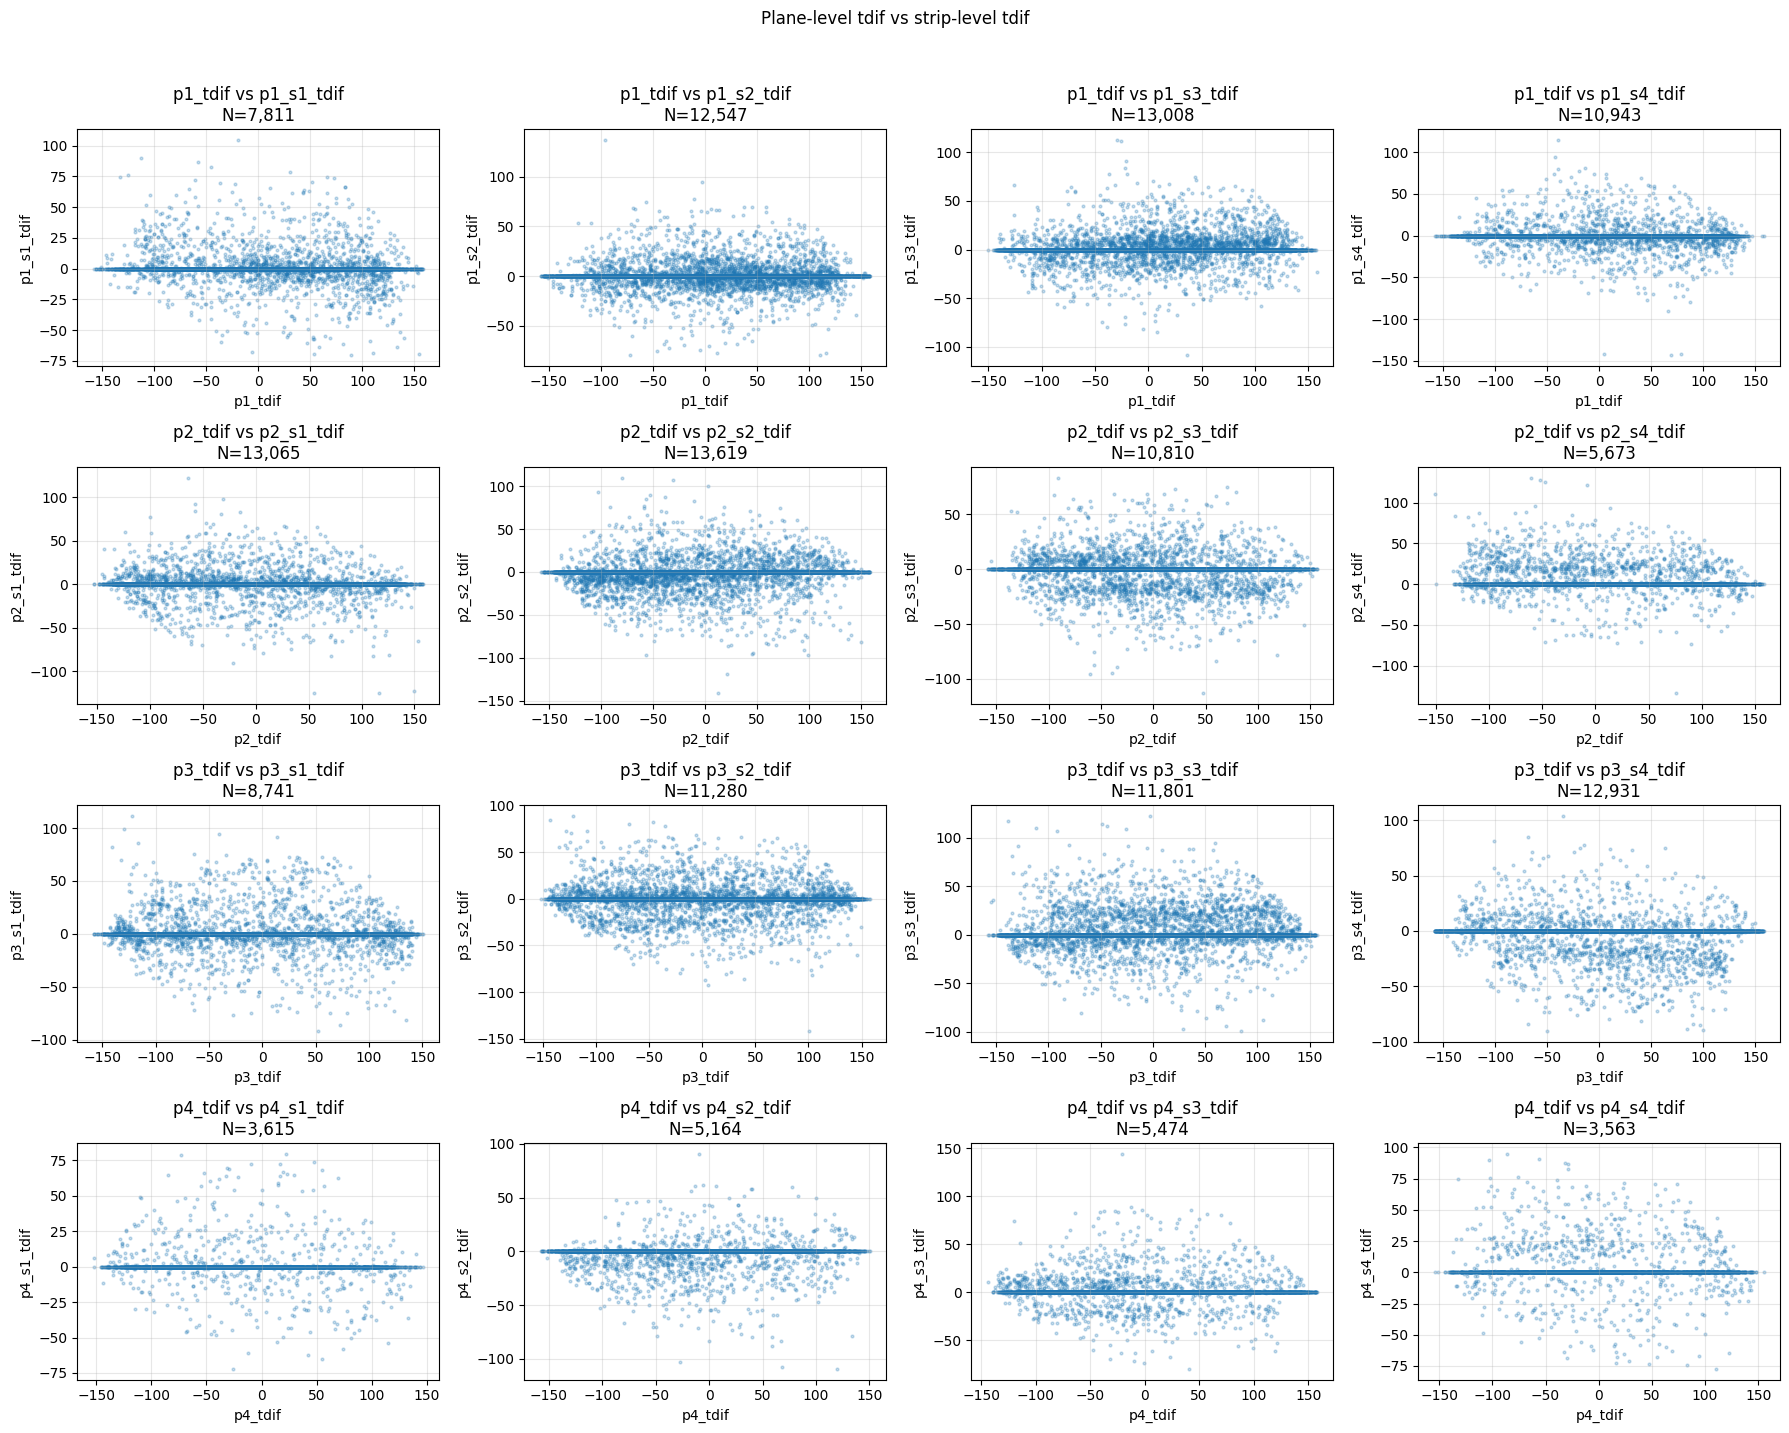

In [13]:
def plot_plane_tdif_vs_strip_tdif_grid(
    df_gated,
    max_points_per_panel: int = 50_000,
    alpha: float = 0.25,
    point_size: float = 4,
):
    fig, axes = plt.subplots(4, 4, figsize=(18, 14), squeeze=False)

    for plane in range(1, 5):
        x_col = f"p{plane}_tdif"

        for strip in range(1, 5):
            y_col = f"p{plane}_s{strip}_tdif"
            ax = axes[plane - 1][strip - 1]

            if x_col not in df_gated.columns or y_col not in df_gated.columns:
                ax.set_title(f"P{plane} S{strip}\nmissing column")
                ax.axis("off")
                continue

            local = df_gated[[x_col, y_col]].copy()
            local[x_col] = pd.to_numeric(local[x_col], errors="coerce")
            local[y_col] = pd.to_numeric(local[y_col], errors="coerce")
            local = local.replace([np.inf, -np.inf], np.nan).dropna()

            # Optional: keep only nonzero timing entries.
            local = local[(local[x_col] != 0) & (local[y_col] != 0)]

            if local.empty:
                ax.set_title(f"P{plane} S{strip}\nno valid data")
                ax.axis("off")
                continue

            if len(local) > max_points_per_panel:
                local = local.sample(max_points_per_panel, random_state=RANDOM_SEED)
            
            x = local[x_col]
            y = local[y_col] - local[x_col]
            cond = (y != 0)
            x = x[cond]
            y = y[cond]

            x = 200 * x
            y = 200 * y

            ax.scatter(
                x,
                y,
                s=point_size,
                alpha=alpha,
            )

            ax.set_title(f"p{plane}_tdif vs p{plane}_s{strip}_tdif\nN={len(local):,}")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.3)

    fig.suptitle("Plane-level tdif vs strip-level tdif", y=1.02)
    fig.tight_layout()
    plt.show()


plot_plane_tdif_vs_strip_tdif_grid(df_gated)